In [1]:
import numpy as np
import pandas as pd
import data_clean_utils
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [2]:
import dagshub
dagshub.init(repo_owner='inductive-anks1', repo_name='Swiggy-Delivery-Time-Prediction-DVC', mlflow=True)

Accessing as inductive-anks1

Initialized MLflow to track repo "inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC"

Repository inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC initialized!

In [3]:
import mlflow

In [4]:
# set the tracking server

mlflow.set_tracking_uri("https://dagshub.com/inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC.mlflow")

In [5]:
# mlflow experiment

mlflow.set_experiment("Exp 6 - Final Estimator")

<Experiment: artifact_location='mlflow-artifacts:/5ec5bf867b344c2297a94168b3636a19', creation_time=1736915240980, experiment_id='2', last_update_time=1736915240980, lifecycle_stage='active', name='Exp 6 - Final Estimator', tags={}>

In [6]:
from sklearn import set_config

set_config(transform_output="pandas")

# Load the Data

In [7]:
# load the data

df = pd.read_csv('../data/swiggy_cleaned.csv')

df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


# Clean Data

In [8]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [9]:
df.shape

(45502, 27)

In [10]:
df = df.sample(n=30000, random_state=42).reset_index(drop=True)

In [11]:
# drop columns not required for model input

columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,30.0,4.8,sunny,jam,1,buffet,scooter,1.0,no,metropolitian,18,0,10.0,night,12.417488,long
1,23.0,5.0,fog,jam,2,buffet,scooter,1.0,no,metropolitian,36,0,15.0,night,NaN,NaN
2,22.0,4.5,windy,low,2,drinks,scooter,0.0,no,metropolitian,14,1,5.0,night,4.406344,short
3,27.0,4.5,sandstorms,medium,2,meal,motorcycle,1.0,no,metropolitian,23,0,15.0,afternoon,4.537513,short
4,37.0,4.5,fog,medium,1,drinks,scooter,1.0,no,urban,17,0,10.0,afternoon,6.120942,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,23.0,4.8,sandstorms,low,0,meal,motorcycle,0.0,no,metropolitian,22,0,10.0,night,17.137936,very_long
29996,25.0,4.9,sandstorms,medium,0,meal,motorcycle,1.0,no,metropolitian,14,0,10.0,afternoon,7.646983,medium
29997,24.0,4.9,sunny,medium,1,snack,motorcycle,0.0,no,urban,11,0,10.0,evening,9.220373,medium
29998,31.0,4.4,cloudy,low,0,snack,motorcycle,1.0,no,metropolitian,38,1,5.0,night,17.078665,very_long


In [12]:
# check for missing values

df.isna().sum()

age                    1237
ratings                1279
weather                 344
traffic                 333
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     652
festival                152
city_type               790
time_taken                0
is_weekend                0
pickup_time_minutes    1082
order_time_of_day      1379
distance               2398
distance_type          2398
dtype: int64

In [13]:
# check for duplicates

df.duplicated().sum()

0

<Axes: >

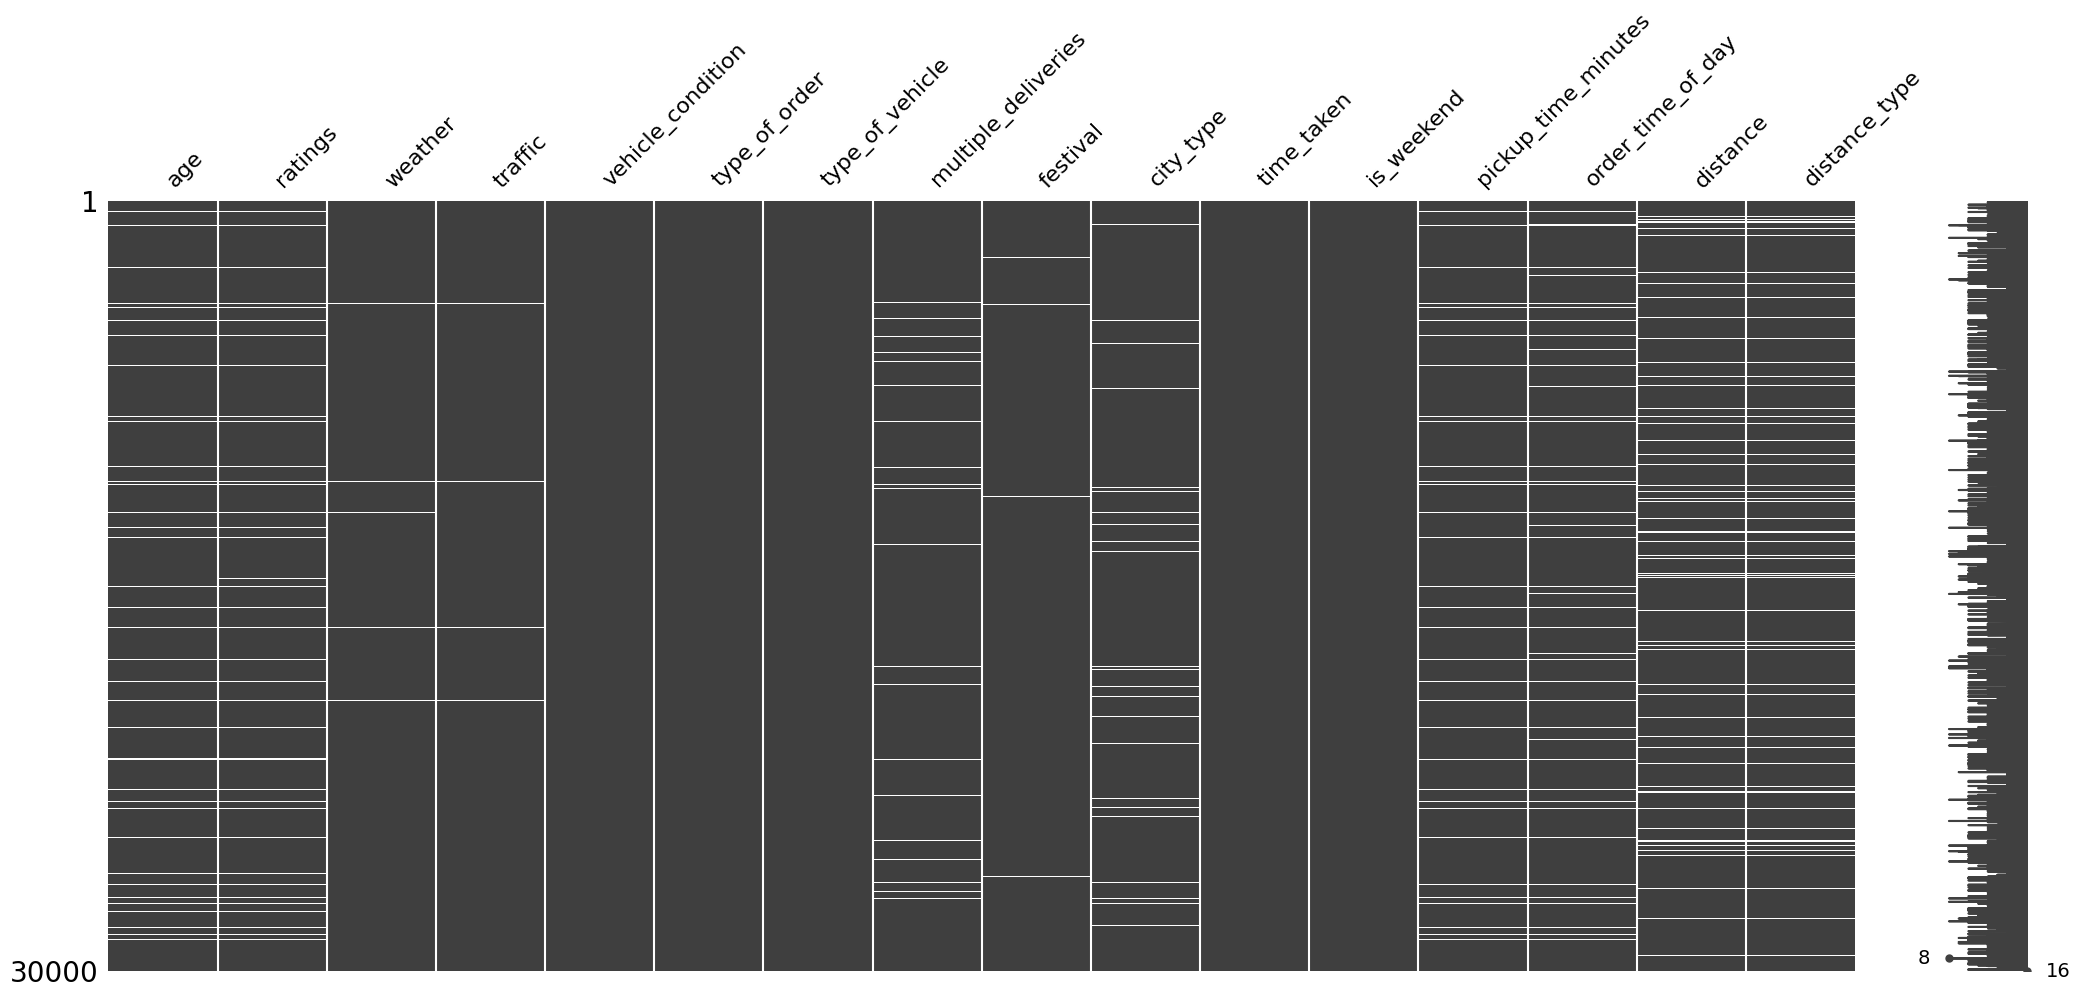

In [14]:
import missingno as msno

msno.matrix(df)

In [15]:
# columns that have missing values

missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

# Drop Missing values

In [16]:
temp_df = df.copy().dropna()

In [17]:
# split into X and y

X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,30.0,4.8,sunny,jam,1,buffet,scooter,1.0,no,metropolitian,0,10.0,night,12.417488,long
2,22.0,4.5,windy,low,2,drinks,scooter,0.0,no,metropolitian,1,5.0,night,4.406344,short
3,27.0,4.5,sandstorms,medium,2,meal,motorcycle,1.0,no,metropolitian,0,15.0,afternoon,4.537513,short
4,37.0,4.5,fog,medium,1,drinks,scooter,1.0,no,urban,0,10.0,afternoon,6.120942,medium
5,39.0,4.6,sunny,jam,1,meal,scooter,1.0,no,metropolitian,0,10.0,evening,7.489981,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,23.0,4.8,sandstorms,low,0,meal,motorcycle,0.0,no,metropolitian,0,10.0,night,17.137936,very_long
29996,25.0,4.9,sandstorms,medium,0,meal,motorcycle,1.0,no,metropolitian,0,10.0,afternoon,7.646983,medium
29997,24.0,4.9,sunny,medium,1,snack,motorcycle,0.0,no,urban,0,10.0,evening,9.220373,medium
29998,31.0,4.4,cloudy,low,0,snack,motorcycle,1.0,no,metropolitian,1,5.0,night,17.078665,very_long


In [18]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (19873, 15)
The shape of test data is (4969, 15)


In [20]:
# missing values in train data

X_train.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
is_weekend             0
pickup_time_minutes    0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [21]:
# transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [22]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [23]:
# percentage of rows in data having missing values

(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)


0.0

# Pre-Processing Pipeline

In [24]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather',
                    'type_of_order',
                    'type_of_vehicle',
                    "festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [25]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [26]:
X_train.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
is_weekend             0
pickup_time_minutes    0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [27]:
# # features to fill values with mode

# features_to_fill_mode = ['multiple_deliveries','festival','city_type']
# features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

# features_to_fill_missing

In [28]:
# # simple imputer to fill categorical vars with mode

# simple_imputer = ColumnTransformer(transformers=[
#     ("mode_imputer",SimpleImputer(strategy="most_frequent",add_indicator=True),features_to_fill_mode),
#     ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing",add_indicator=True),features_to_fill_missing)
# ],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

# simple_imputer

In [29]:
# simple_imputer.fit_transform(X_train)

In [30]:
# simple_imputer.fit_transform(X_train).isna().sum()

In [31]:
# knn imputer

# knn_imputer = KNNImputer(n_neighbors=5)

In [32]:
# do basic preprocessing

num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [33]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [34]:
# unique categories the ordinal columns

for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['high' 'jam' 'medium' 'low']
distance_type ['medium' 'short' 'long' 'very_long']


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder

# Assuming num_cols, nominal_cat_cols, ordinal_cat_cols, traffic_order, and distance_type_order are defined
preprocessor = ColumnTransformer(
    transformers=[
        ("scale", MinMaxScaler(), num_cols),
        ("nominal_encode", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nominal_cat_cols),
        ("ordinal_encode", OrdinalEncoder(categories=[traffic_order, distance_type_order],
                                          handle_unknown="use_encoded_value", unknown_value=-1), ordinal_cat_cols)
    ],
    remainder="passthrough",  # Pass through all other columns unchanged
    n_jobs=-1,                # Parallel processing
    verbose_feature_names_out=False  # Use original feature names without transformation details
)

preprocessor

ColumnTransformer(n_jobs=-1, remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [36]:
# build the pipeline

processing_pipeline = Pipeline(steps=[
                                # ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor)
                                # ("knn_imputer",knn_imputer)
                            ])

processing_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(n_jobs=-1, remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'ratings',
                                                   'pickup_time_minutes',
                                                   'distance']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False))])

In [37]:
# do data preprocessing

X_train_trans = processing_pipeline.fit_transform(X_train)

X_test_trans = processing_pipeline.transform(X_test)

In [38]:
X_train_trans

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,...,city_type_semi-urban,city_type_urban,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
863,1.000000,0.96,0.0,0.238709,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0,0.0
26894,0.947368,1.00,0.0,0.160572,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,0.0,2,1.0
16315,0.473684,0.96,0.0,0.548442,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0,1.0
781,0.052632,0.96,0.0,0.539291,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,1,1.0
12181,0.210526,1.00,0.0,0.777767,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,3.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26080,0.947368,0.96,1.0,0.800318,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,3.0,1,1.0
6481,0.210526,0.92,0.5,0.944363,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0,1.0
1065,0.421053,0.92,0.5,0.562492,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,3.0,2.0,1,1.0
19048,0.684211,1.00,0.5,0.949045,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,0,1.0


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

In [40]:
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import StackingRegressor

In [41]:
# build the best models

best_rf_params = {'n_estimators': 479,
 'criterion': 'squared_error',
 'max_depth': 17,
 'max_features': None,
 'min_samples_split': 9,
 'min_samples_leaf': 2,
 'max_samples': 0.6603673526197067}

best_lgbm_params = {'n_estimators': 154,
 'max_depth': 27,
 'learning_rate': 0.22234435854395157,
 'subsample': 0.7592213724048168,
 'min_child_weight': 20,
 'min_split_gain': 0.004604680609280751,
 'reg_lambda': 97.81002379097947}

best_rf = RandomForestRegressor(**best_rf_params)
best_lgbm = LGBMRegressor(**best_lgbm_params)

lr = LinearRegression()

In [42]:
# build the stacking regressor

stacking_reg = StackingRegressor(estimators=[("rf",best_rf),
                                            ("lgbm",best_lgbm)],
                                final_estimator=lr,
                                cv=5,n_jobs=-1)

# build transformed regressor

model = TransformedTargetRegressor(regressor=stacking_reg,
                                    transformer=pt)

# train the model
model.fit(X_train_trans,y_train)

/home/inductive_anks/.local/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 353
[LightGBM] [Info] Number of data points in the train set: 19873, number of used features: 25
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001997 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 15899, number of used features: 25
[LightGBM] [Info] Start training from score -0.003899
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003066 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough

TransformedTargetRegressor(regressor=StackingRegressor(cv=5,
                                                       estimators=[('rf',
                                                                    RandomForestRegressor(max_depth=17,
                                                                                          max_features=None,
                                                                                          max_samples=0.6603673526197067,
                                                                                          min_samples_leaf=2,
                                                                                          min_samples_split=9,
                                                                                          n_estimators=479)),
                                                                   ('lgbm',
                                                                    LGBMRegressor(learning_rate=0.22234435854395157,
                                                                                  max_depth=27,
                                                                                  min_child_weight=20,
                                                                                  min_split_gain=0.004604680609280751,
                                                                                  n_estimators=154,
                                                                                  reg_lambda=97.81002379097947,
                                                                                  subsample=0.7592213724048168))],
                                                       final_estimator=LinearRegression(),
                                                       n_jobs=-1),
                           transformer=PowerTransformer())

In [43]:
# get the train and test predictions

y_train_pred = model.predict(X_train_trans)
y_test_pred = model.predict(X_test_trans)
 
# calculate the train and test mae

train_mae = mean_absolute_error(y_train,y_train_pred)
test_mae = mean_absolute_error(y_test,y_test_pred)

# calculate the r2 scores

train_r2 = r2_score(y_train,y_train_pred)
test_r2 = r2_score(y_test,y_test_pred)

# calculate cross val scores

cv_scores = cross_val_score(model,
                            X_train_trans,
                            y_train,cv=3,
                            scoring="neg_mean_absolute_error",
                            n_jobs=-1)

/home/inductive_anks/.local/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/inductive_anks/.local/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/inductive_anks/.local/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(
/home/inductive_anks/.local/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(
/home/inductive_anks/.local/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042746 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 13249, number of used features: 25
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 13249, number of used features: 25
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bi

/home/inductive_anks/.local/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/inductive_anks/.local/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/inductive_anks/.local/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [44]:
-cv_scores

array([3.12777679, 3.09898189, 3.12409651])

In [45]:
# log with mlflow

with mlflow.start_run():
    # set tags
    mlflow.set_tag("model","stacking regressor")

    # log parameters
    mlflow.log_params(stacking_reg.get_params())

    # log metrics
    mlflow.log_metric("train_mae",train_mae)
    mlflow.log_metric("test_mae",test_mae)
    mlflow.log_metric("train_r2",train_r2)
    mlflow.log_metric("test_r2",test_r2)
    mlflow.log_metric("cv_score",-(cv_scores.mean()))

    # log the stacking regressor
    mlflow.sklearn.log_model(stacking_reg,"model")

2025/01/18 22:12:45 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.
2025/01/18 22:12:45 INFO mlflow.tracking._tracking_service.client: 🏃 View run marvelous-lamb-893 at: https://dagshub.com/inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC.mlflow/#/experiments/2/runs/bd7ae58340844640a6f3a7245d8dd945.
2025/01/18 22:12:45 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/inductive-anks1/Swiggy-Delivery-Time-Prediction-DVC.mlflow/#/experiments/2.
